In [9]:
!pip install -q datasets matplotlib pandas

import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from PIL import Image

print("[STATUS] Downloading Official Oxford-102 Flowers dataset...")

dataset = load_dataset("dpdl-benchmark/oxford_flowers102", split="train")

print("Dataset fully loaded into memory!")

[STATUS] Downloading Official Oxford-102 Flowers dataset...


README.md:   0%|          | 0.00/3.50k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/418M [00:00<?, ?B/s]

data/test-00000-of-00006.parquet:   0%|          | 0.00/420M [00:00<?, ?B/s]

data/test-00001-of-00006.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

...

data/validation-00000-of-00001.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1020 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6149 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1020 [00:00<?, ? examples/s]

Dataset fully loaded into memory!


In [10]:
import numpy as np
import pandas as pd

print("[STATUS] Starting deep dataset inspection...")

#Convert the dataset info to a quick-access format
sample_size = min(len(dataset), 500)  #Scan a subset of 500 items for lightning fast stats
image_sizes = []
labels = []

#Loop through the data to collect statistics
for i in range(sample_size):
    item = dataset[i]
    img = item['image']
    image_sizes.append(img.size)
    labels.append(item['label'])

#Convert data to numpy arrays for calculation
image_sizes = np.array(image_sizes)
widths = image_sizes[:, 0]
heights = image_sizes[:, 1]
unique_classes = set(labels)

print("\n=== 📋 DATASET STATISTICAL REPORT ===")
print(f"🔹 Total Examples Checked: {sample_size}")
print(f"🔹 Number of Unique Classes Found: {len(unique_classes)}")
print(f"🔹 Minimum Image Resolution: {widths.min()}x{heights.min()} pixels")
print(f"🔹 Maximum Image Resolution: {widths.max()}x{heights.max()} pixels")
print(f"🔹 Average Image Dimensions: {int(widths.mean())}x{int(heights.mean())} pixels")
print("=====================================\n")
print("[STATUS] Statistics gathered. Ready to visualize samples!")

[STATUS] Starting deep dataset inspection...

=== 📋 DATASET STATISTICAL REPORT ===
🔹 Total Examples Checked: 500
🔹 Number of Unique Classes Found: 102
🔹 Minimum Image Resolution: 500x500 pixels
🔹 Maximum Image Resolution: 857x883 pixels
🔹 Average Image Dimensions: 623x538 pixels

[STATUS] Statistics gathered. Ready to visualize samples!


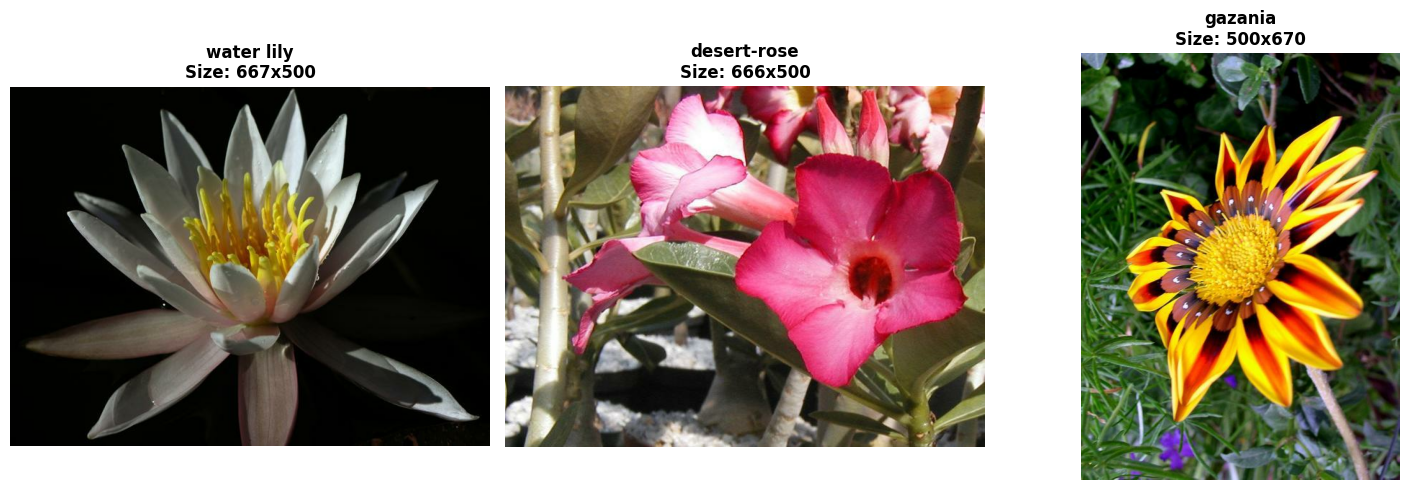

[STATUS] Sample gallery rendered successfully!


In [12]:
import matplotlib.pyplot as plt

features = dataset.features
has_names = 'label' in features and hasattr(features['label'], 'names')

#Create a clean 1 row x 3 columns display grid
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx in range(3):
    sample = dataset[idx]
    img = sample['image']
    label_id = sample['label']

    #Get the text name if available
    class_text = features['label'].names[label_id] if has_names else f"Class ID: {label_id}"

    #Render onto the grid
    axes[idx].imshow(img)
    axes[idx].set_title(f"{class_text}\nSize: {img.size[0]}x{img.size[1]}", fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
print("[STATUS] Sample gallery rendered successfully!")